# Analiza sieci społecznościowych społeczności muzycznych Reddita

Notebook przedstawia analizę relacji między użytkownikami wybranych muzycznych subredditów. Celem jest zbadanie, jak użytkownicy wchodzą ze sobą w interakcje, które osoby zajmują najbardziej centralne pozycje w strukturze dyskusji oraz czy w obrębie społeczności występują wyraźne klastry komunikacyjne.

## Założenia analizy sieciowej

W analizie sieciowej każdy użytkownik Reddita jest traktowany jako węzeł (*node*), a relacja odpowiedzi między użytkownikami jako krawędź (*edge*). Krawędź jest skierowana: `author -> parent_author`, co oznacza, że użytkownik `author` odpowiedział na komentarz użytkownika `parent_author`.

Wagi krawędzi (`weight`) oznaczają liczbę interakcji między tą samą parą użytkowników. Jeśli użytkownik A kilkukrotnie odpowiadał użytkownikowi B, relacja A → B otrzymuje większą wagę. Taka konstrukcja grafu pozwala badać zarówno ogólną aktywność użytkowników, jak i ich pozycję w strukturze rozmów.

Interpretacja grafu:

- większa liczba krawędzi oznacza większą intensywność interakcji,
- wysoki stopień węzła może świadczyć o częstym uczestnictwie w rozmowach,
- wysoka centralność pośrednictwa może wskazywać użytkowników łączących różne części dyskusji,
- wykryte społeczności oznaczają grupy użytkowników częściej komunikujących się między sobą niż z resztą sieci.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from pathlib import Path
from collections import Counter
from itertools import combinations

try:
    from community import community_louvain

    LOUVAIN_AVAILABLE = True
except ImportError:
    community_louvain = None
    LOUVAIN_AVAILABLE = False

try:
    import plotly.graph_objects as go

    PLOTLY_AVAILABLE = True
except ImportError:
    go = None
    PLOTLY_AVAILABLE = False

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"

FIGURES_DIR = OUTPUTS_DIR / "figures"
REPORTS_DIR = OUTPUTS_DIR / "reports"
CHECKPOINT_DIR = DATA_DIR / "checkpoints"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "processed" / "all_subreddits_sample.csv"

SUBREDDIT_LABELS = {
    "Metal": "Metal",
    "hiphopheads": "Hip-hop",
    "popheads": "Pop",
    "indieheads": "Indie",
}

def subreddit_display(name: str) -> str:
    return SUBREDDIT_LABELS.get(str(name), str(name))

def save_plotly_png(figure, filename: str) -> None:
    try:
        figure.write_image(FIGURES_DIR / filename)
    except Exception as exc:
        print(f"Nie zapisano wykresu Plotly do PNG ({filename}): {exc}")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

df = pd.read_csv(DATA_PATH)

required_columns = {"author", "parent_id", "comment_id", "subreddit"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Brakuje wymaganych kolumn: {missing_columns}")

df = df.copy()
df["author"] = df["author"].astype(str)
df["parent_id"] = df["parent_id"].astype(str)
df["comment_id"] = df["comment_id"].astype(str)
df["subreddit"] = df["subreddit"].astype(str)

bot_pattern = r"bot$|automod|moderator|transcrib|helper"
valid_mask = (
    df["author"].notna()
    & ~df["author"].isin(["[deleted]", "[removed]", "nan", "None"])
    & ~df["author"].str.lower().str.contains(bot_pattern, regex=True, na=False)
)
df = df.loc[valid_mask].copy()

summary = pd.DataFrame(
    {
        "warto??": [
            len(df),
            df["author"].nunique(),
            df["subreddit"].nunique(),
            ", ".join(sorted(df["subreddit"].unique())),
        ]
    },
    index=[
        "liczba komentarzy po czyszczeniu",
        "liczba unikalnych u?ytkownik?w",
        "liczba subreddit?w",
        "analizowane subreddity",
    ],
)

summary.to_csv(REPORTS_DIR / "network_dataset_summary.csv")
summary

,wartość
liczba komentarzy po czyszczeniu,2541741
liczba unikalnych użytkowników,201615
liczba subredditów,4
analizowane subreddity,"Metal, hiphopheads, indieheads, popheads"


In [4]:
# Wczytanie oczyszczonego df z checkpointu (jeśli dostępny)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
df_checkpoint_path = CHECKPOINT_DIR / "network_df_checkpoint.pkl"
if "df" in globals():
    print("df już istnieje w pamięci — pomijam wczytywanie checkpointu.")
elif df_checkpoint_path.exists():
    df = pd.read_pickle(df_checkpoint_path)
    print(f"Wczytano df z: {df_checkpoint_path}")
    print(f"df shape: {df.shape}")
    print(f"Kolumny: {df.columns.tolist()}")
else:
    print(f"Brak checkpointu: {df_checkpoint_path}")

df już istnieje w pamięci — pomijam wczytywanie checkpointu.


Wstępne czyszczenie usuwa konta techniczne, boty oraz komentarze bez użytecznego autora. Dzięki temu dalsze metryki odnoszą się przede wszystkim do realnych interakcji użytkowników, a nie do automatycznych odpowiedzi systemowych.

## 1. Budowa grafów interakcji

In [5]:
replies = df[df['parent_id'].str.startswith('t1_', na=False)].copy()
replies['parent_comment_id'] = replies['parent_id'].str.replace('t1_', '', regex=False)

edges = replies.merge(
    df[['comment_id', 'author']].rename(columns={'author': 'parent_author'}),
    left_on='parent_comment_id',
    right_on='comment_id',
    how='inner'
)

# Usuwamy odpowiedzi użytkownika do samego siebie, ponieważ nie tworzą relacji społecznej.
edges = edges[edges['author'] != edges['parent_author']].copy()

# Agregujemy powtarzające się odpowiedzi tej samej pary użytkowników.
weighted_edges = (
    edges
    .groupby(['subreddit', 'author', 'parent_author'], as_index=False)
    .size()
    .rename(columns={'size': 'weight'})
)

weighted_edges.to_csv(REPORTS_DIR / 'weighted_network_edges.csv', index=False)
weighted_edges.head(10)

,subreddit,author,parent_author,weight
0,Metal,---________----,Anrod459,1
1,Metal,---________----,C0rona,1
2,Metal,-AestheticsOfHate-,Sev_Obzen,2
3,Metal,-AestheticsOfHate-,thr33beggars,1
4,Metal,-Bunny-,meshuggahnaut,1
5,Metal,-Damien-,_lurpak_,1
6,Metal,-Davo,Krakenborn,1
7,Metal,-Davo,ManDe1orean,1
8,Metal,-Davo,cat_intervention,1
9,Metal,-Davo,one_fishBoneFish,1


In [6]:
graphs = {}
for subreddit, group in weighted_edges.groupby('subreddit'):
    graph = nx.DiGraph()
    for row in group.itertuples(index=False):
        graph.add_edge(row.author, row.parent_author, weight=int(row.weight))
    graphs[subreddit] = graph

network_overview = pd.DataFrame([
    {
        'subreddit': subreddit,
        'nodes': graph.number_of_nodes(),
        'edges': graph.number_of_edges(),
        'weighted_interactions': sum(data['weight'] for _, _, data in graph.edges(data=True))
    }
    for subreddit, graph in graphs.items()
]).sort_values('subreddit')

network_overview.to_csv(REPORTS_DIR / 'network_overview.csv', index=False)
network_overview

,subreddit,nodes,edges,weighted_interactions
0,Metal,10996,45461,59861
1,hiphopheads,83153,617923,823285
2,indieheads,32131,142887,219390
3,popheads,27142,317417,436020


In [7]:
# Wczytanie grafów z checkpointu (jeśli potrzebne)
import pickle

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
graphs_checkpoint_path = CHECKPOINT_DIR / "network_graphs_checkpoint.pkl"
if all(name in globals() for name in ["weighted_edges", "graphs", "network_overview"]):
    print("Grafy i krawędzie już istnieją w pamięci — pomijam wczytywanie checkpointu.")
elif graphs_checkpoint_path.exists():
    with open(graphs_checkpoint_path, "rb") as handle:
        checkpoint = pickle.load(handle)
    weighted_edges = checkpoint.get("weighted_edges")
    graphs = checkpoint.get("graphs", {})
    network_overview = checkpoint.get("network_overview")
    print(f"Wczytano grafy z: {graphs_checkpoint_path}")
    print(f"Liczba grafów: {len(graphs)}")
    if hasattr(weighted_edges, "shape"):
        print(f"weighted_edges shape: {weighted_edges.shape}")
    if hasattr(network_overview, "shape"):
        print(f"network_overview shape: {network_overview.shape}")
else:
    print(f"Brak checkpointu: {graphs_checkpoint_path}")

Grafy i krawędzie już istnieją w pamięci — pomijam wczytywanie checkpointu.


In [8]:
# Zapis grafów do checkpointu
import pickle

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
graphs_checkpoint_path = CHECKPOINT_DIR / "network_graphs_checkpoint.pkl"
with open(graphs_checkpoint_path, "wb") as handle:
    pickle.dump(
        {
            "weighted_edges": weighted_edges,
            "graphs": graphs,
            "network_overview": network_overview,
        },
        handle,
    )

print(f"Zapisano grafy do: {graphs_checkpoint_path}")
print(f"Liczba grafów: {len(graphs)}")
print(f"weighted_edges shape: {weighted_edges.shape}")
print(f"network_overview shape: {network_overview.shape}")

Zapisano grafy do: ..\data\checkpoints\network_graphs_checkpoint.pkl
Liczba grafów: 4
weighted_edges shape: (1123688, 4)
network_overview shape: (4, 4)


Tabela pokazuje podstawowy rozmiar grafów dla poszczególnych subredditów. Liczba krawędzi oznacza liczbę unikalnych relacji między parami użytkowników, natomiast liczba ważonych interakcji uwzględnia powtarzalność odpowiedzi między tymi samymi osobami.

## 2. Podstawowe statystyki sieci

In [9]:
def safe_largest_component_size(graph_undirected):
    if graph_undirected.number_of_nodes() == 0:
        return 0
    return len(max(nx.connected_components(graph_undirected), key=len))

basic_metrics = []
for subreddit, graph in graphs.items():
    graph_undirected = graph.to_undirected()
    degrees = [degree for _, degree in graph_undirected.degree()]
    components = list(nx.connected_components(graph_undirected)) if graph_undirected.number_of_nodes() > 0 else []
    basic_metrics.append({
        'subreddit': subreddit,
        'nodes': graph.number_of_nodes(),
        'edges': graph.number_of_edges(),
        'avg_degree': round(float(np.mean(degrees)), 3) if degrees else 0,
        'max_degree': max(degrees) if degrees else 0,
        'density': round(nx.density(graph_undirected), 6),
        'connected_components': len(components),
        'largest_component_size': safe_largest_component_size(graph_undirected),
        'largest_component_share': round(safe_largest_component_size(graph_undirected) / graph.number_of_nodes(), 4) if graph.number_of_nodes() else 0
    })

basic_metrics_df = pd.DataFrame(basic_metrics).sort_values('subreddit')
basic_metrics_df.to_csv(REPORTS_DIR / 'network_basic_metrics.csv', index=False)
basic_metrics_df

,subreddit,nodes,edges,avg_degree,max_degree,density,connected_components,largest_component_size,largest_component_share
0,Metal,10996,45461,6.371,440,0.000579,286,10385,0.9444
1,hiphopheads,83153,617923,11.960,4327,0.000144,668,81753,0.9832
2,indieheads,32131,142887,6.978,961,0.000217,568,30905,0.9618
3,popheads,27142,317417,18.537,2209,0.000683,199,26700,0.9837


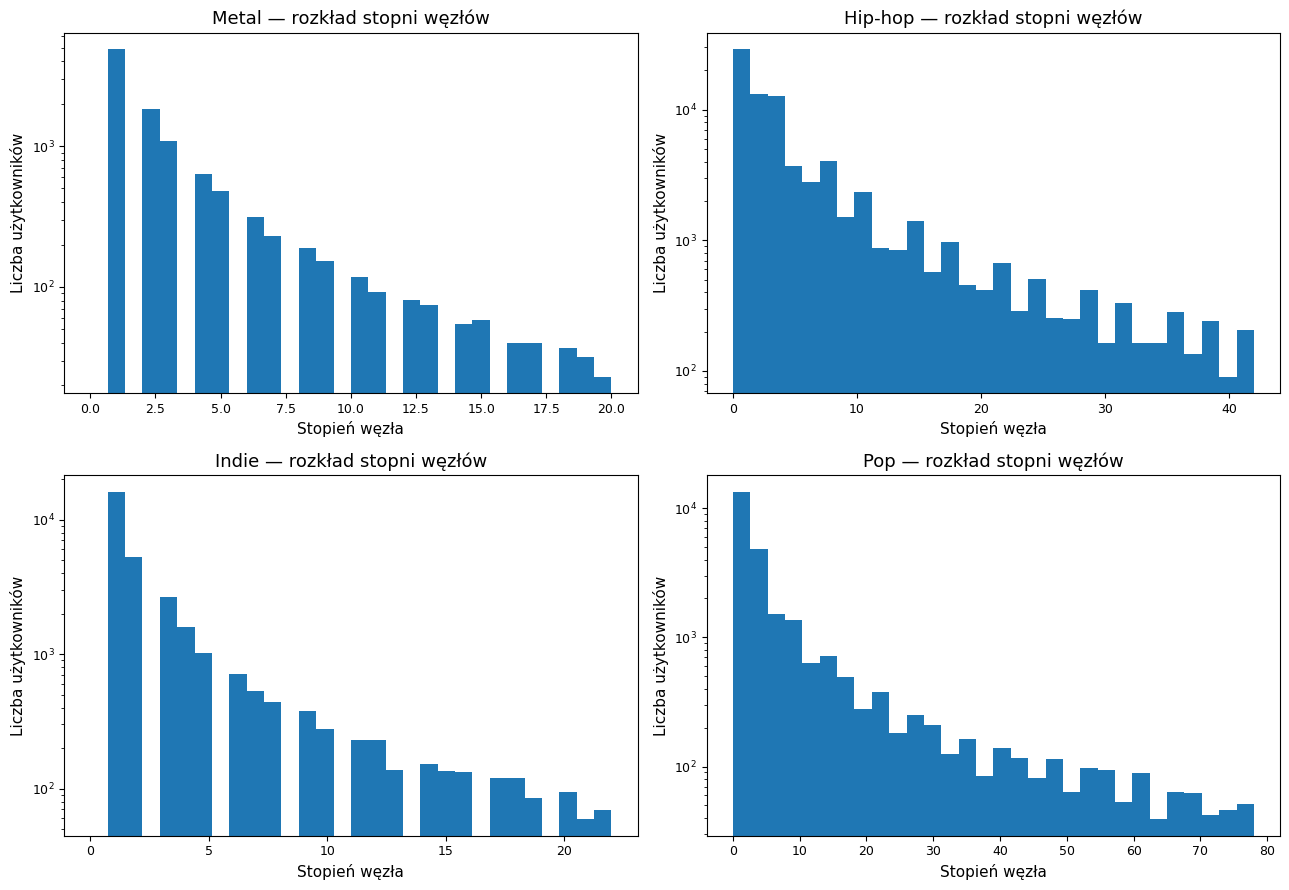

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (subreddit, graph) in zip(axes, sorted(graphs.items())):
    degrees = [degree for _, degree in graph.to_undirected().degree()]
    if not degrees:
        ax.set_title(f"{subreddit_display(subreddit)} — brak danych")
        ax.axis("off")
        continue
    upper_limit = max(1, int(np.percentile(degrees, 95)))
    ax.hist(degrees, bins=30, range=(0, upper_limit))
    ax.set_title(f"{subreddit_display(subreddit)} — rozkład stopni węzłów")
    ax.set_xlabel("Stopień węzła")
    ax.set_ylabel("Liczba użytkowników")
    ax.set_yscale("log")

for ax in axes[len(graphs):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "degree_distribution_networks.png", dpi=150, bbox_inches="tight")
plt.show()

Rozkład stopni węzłów pozwala ocenić, czy rozmowy są rozproszone między wieloma użytkownikami, czy koncentrują się wokół niewielkiej grupy bardziej aktywnych kont. Skala logarytmiczna ułatwia odczyt, ponieważ w sieciach społecznościowych większość użytkowników ma niewiele połączeń, a tylko nieliczni osiągają bardzo wysoką liczbę relacji.

## 3. Analiza centralności

In [11]:
def normalize_series(series):
    max_value = series.max()
    if pd.isna(max_value) or max_value == 0:
        return series * 0
    return series / max_value

def calculate_centralities(graph, sample_k=500, seed=42):
    if graph.number_of_nodes() == 0:
        return pd.DataFrame()
    
    degree_centrality = nx.degree_centrality(graph)
    pagerank = nx.pagerank(graph, weight='weight')
    
    k = min(sample_k, max(1, graph.number_of_nodes() - 1))
    betweenness_centrality = nx.betweenness_centrality(graph, k=k, seed=seed, weight=None)
    
    graph_undirected = graph.to_undirected()
    try:
        eigenvector_centrality = nx.eigenvector_centrality(graph_undirected, max_iter=1000, weight='weight')
    except nx.PowerIterationFailedConvergence:
        eigenvector_centrality = {node: np.nan for node in graph.nodes()}
    
    return pd.DataFrame({
        'degree_centrality': pd.Series(degree_centrality),
        'betweenness_centrality': pd.Series(betweenness_centrality),
        'eigenvector_centrality': pd.Series(eigenvector_centrality),
        'pagerank': pd.Series(pagerank)
    })

centrality_tables = {}
for subreddit, graph in graphs.items():
    centrality_df = calculate_centralities(graph)
    centrality_df['subreddit'] = subreddit
    centrality_df.index.name = 'author'
    centrality_tables[subreddit] = centrality_df

all_centralities = pd.concat(centrality_tables.values()).reset_index()
all_centralities.to_csv(REPORTS_DIR / 'network_centralities.csv', index=False)
all_centralities.head()

,author,degree_centrality,betweenness_centrality,eigenvector_centrality,pagerank,subreddit
0,---________----,0.000273,0.000065,4.711802e-05,0.000031,Metal
1,Anrod459,0.000091,0.000000,2.237331e-07,0.000034,Metal
2,C0rona,0.002183,0.000303,4.969210e-03,0.000116,Metal
3,-AestheticsOfHate-,0.000364,0.000033,7.049951e-04,0.000060,Metal
4,Sev_Obzen,0.000364,0.000000,1.647585e-05,0.000061,Metal


In [12]:
for metric in ['degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'pagerank']:
    top_metric = (
        all_centralities
        .sort_values(['subreddit', metric], ascending=[True, False])
        .groupby('subreddit')
        .head(10)
        [['subreddit', 'author', metric]]
    )
    top_metric.to_csv(REPORTS_DIR / f'top_users_{metric}.csv', index=False)
    display(top_metric)

,subreddit,author,degree_centrality
49,Metal,whoelsebut_rxe,0.055298
104,Metal,sardonic_malcontent,0.054752
38,Metal,Towering_Flesh,0.053934
327,Metal,onairmastering,0.050568
94,Metal,an_altar_of_plagues,0.045839
154,Metal,kaptain_carbon,0.045566
197,Metal,hermaphroditicspork,0.045111
140,Metal,WowboyKid,0.043565
45,Metal,notyourlandlord,0.042565
395,Metal,Samccx19,0.041655


,subreddit,author,betweenness_centrality
49,Metal,whoelsebut_rxe,0.031067
327,Metal,onairmastering,0.030196
104,Metal,sardonic_malcontent,0.028470
38,Metal,Towering_Flesh,0.027189
154,Metal,kaptain_carbon,0.021215
395,Metal,Samccx19,0.018940
94,Metal,an_altar_of_plagues,0.018708
134,Metal,ThePiperMan,0.017837
284,Metal,JKevill,0.017720
45,Metal,notyourlandlord,0.016307


,subreddit,author,eigenvector_centrality
116,Metal,FutureWeapon,0.272859
49,Metal,whoelsebut_rxe,0.239500
140,Metal,WowboyKid,0.215428
154,Metal,kaptain_carbon,0.203477
197,Metal,hermaphroditicspork,0.190673
38,Metal,Towering_Flesh,0.188120
106,Metal,Anish316,0.183582
104,Metal,sardonic_malcontent,0.174142
1161,Metal,impop,0.174028
94,Metal,an_altar_of_plagues,0.170424


,subreddit,author,pagerank
116,Metal,FutureWeapon,0.007367
154,Metal,kaptain_carbon,0.007037
49,Metal,whoelsebut_rxe,0.006327
106,Metal,Anish316,0.005610
38,Metal,Towering_Flesh,0.005607
104,Metal,sardonic_malcontent,0.004867
197,Metal,hermaphroditicspork,0.004769
94,Metal,an_altar_of_plagues,0.004718
165,Metal,the_cramdown,0.004698
45,Metal,notyourlandlord,0.004698


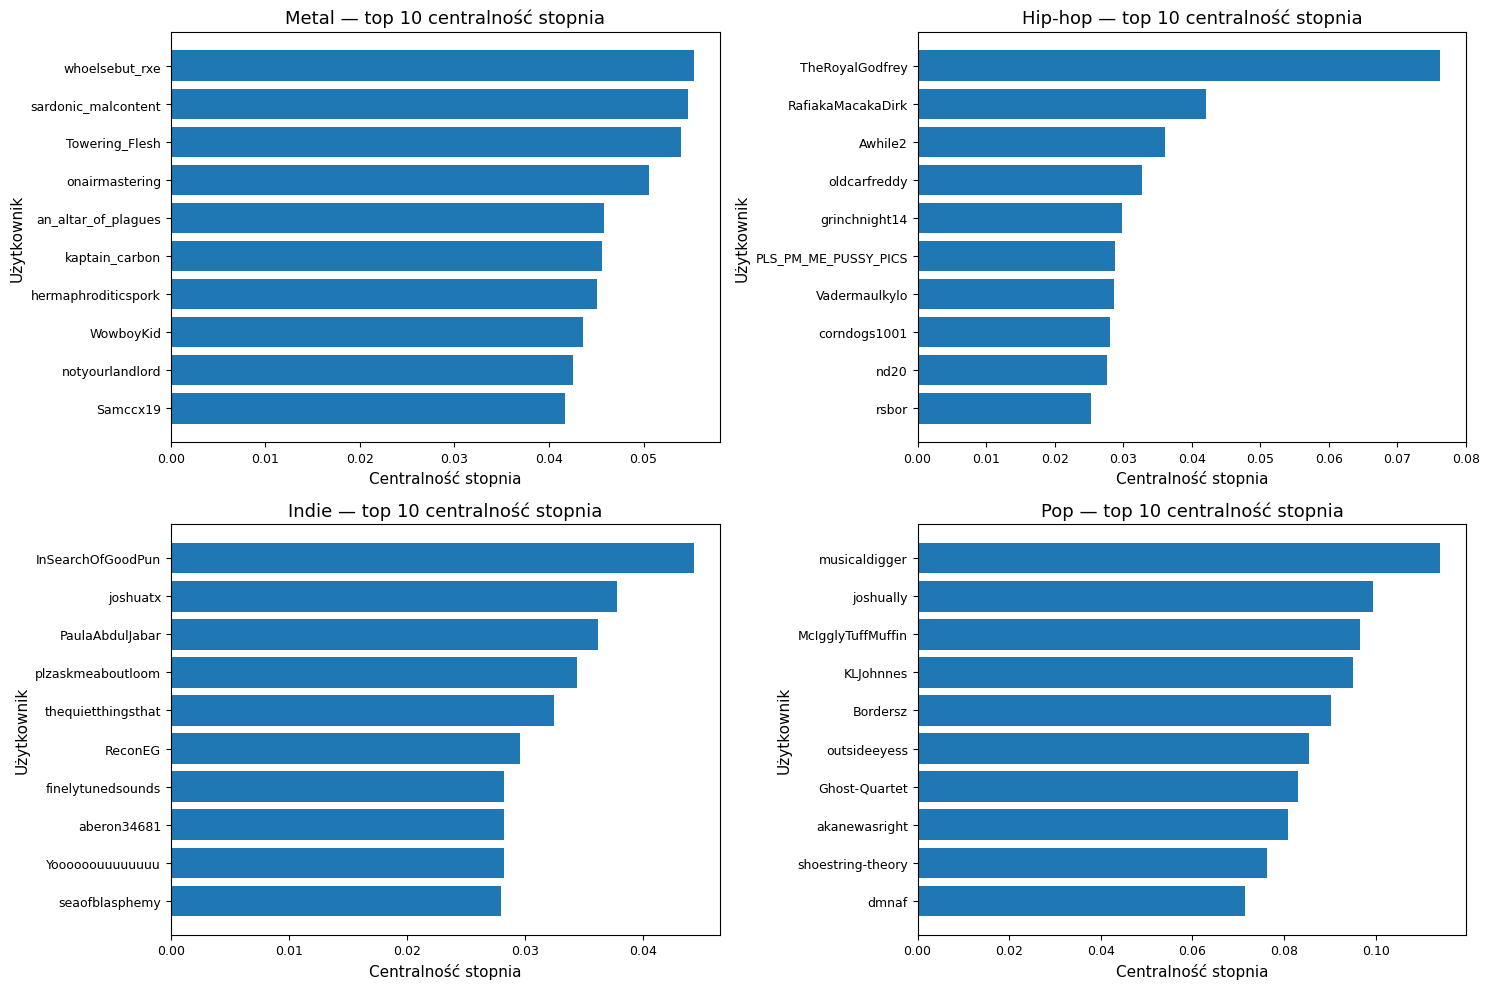

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, (subreddit, centrality_df) in zip(axes, sorted(centrality_tables.items())):
    top = centrality_df.sort_values("degree_centrality", ascending=False).head(10).iloc[::-1]
    ax.barh(top.index, top["degree_centrality"])
    ax.set_title(f"{subreddit_display(subreddit)} — top 10 centralność stopnia")
    ax.set_xlabel("Centralność stopnia")
    ax.set_ylabel("Użytkownik")

for ax in axes[len(centrality_tables):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_degree_centrality.png", dpi=150, bbox_inches="tight")
plt.show()

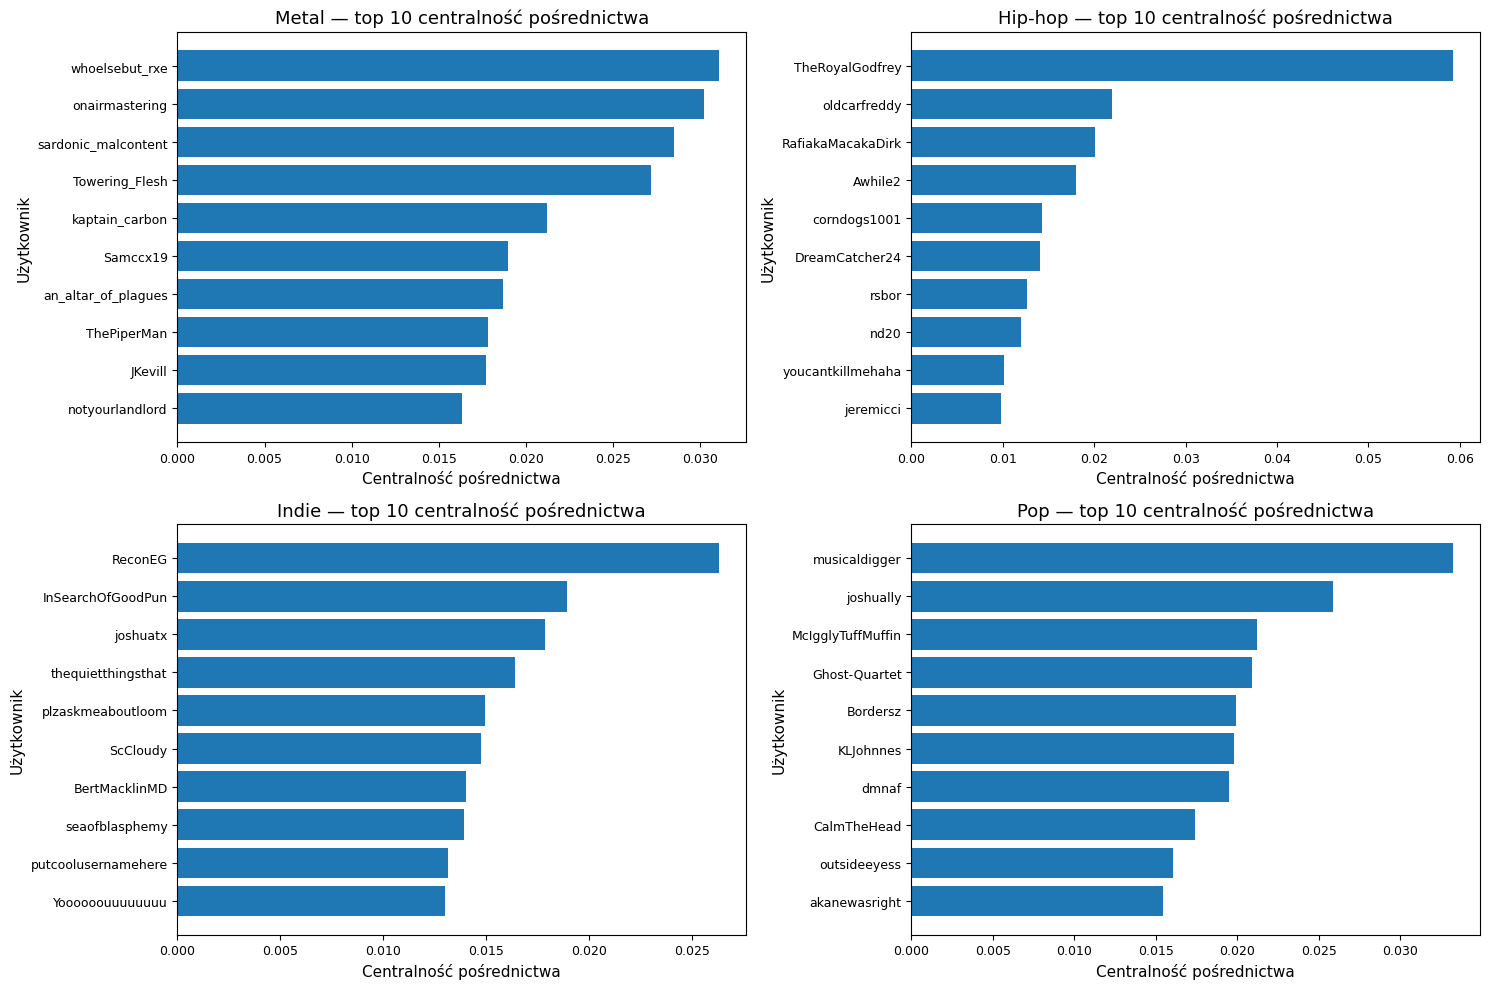

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, (subreddit, centrality_df) in zip(axes, sorted(centrality_tables.items())):
    top = centrality_df.sort_values("betweenness_centrality", ascending=False).head(10).iloc[::-1]
    ax.barh(top.index, top["betweenness_centrality"])
    ax.set_title(f"{subreddit_display(subreddit)} — top 10 centralność pośrednictwa")
    ax.set_xlabel("Centralność pośrednictwa")
    ax.set_ylabel("Użytkownik")

for ax in axes[len(centrality_tables):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_betweenness_centrality.png", dpi=150, bbox_inches="tight")
plt.show()

Metryki centralności pokazują różne typy znaczenia użytkowników w sieci. Degree centrality wskazuje osoby mające wiele bezpośrednich połączeń, betweenness centrality identyfikuje użytkowników pośredniczących między częściami sieci, eigenvector centrality premiuje kontakty z innymi ważnymi użytkownikami, a PageRank pomaga wskazać konta, do których prowadzą istotne relacje odpowiedzi.

## 4. Wykrywanie społeczności i klastrów

In [15]:
community_stats = []
community_assignments = []

for subreddit, graph in graphs.items():
    graph_undirected = graph.to_undirected()
    if graph_undirected.number_of_nodes() == 0:
        continue
    
    if LOUVAIN_AVAILABLE:
        partition = community_louvain.best_partition(graph_undirected, weight='weight', random_state=42)
        modularity = community_louvain.modularity(partition, graph_undirected, weight='weight')
        method = 'Louvain'
    else:
        communities = nx.algorithms.community.greedy_modularity_communities(graph_undirected, weight='weight')
        partition = {node: idx for idx, community in enumerate(communities) for node in community}
        modularity = nx.algorithms.community.modularity(graph_undirected, communities, weight='weight')
        method = 'greedy_modularity'
    
    nx.set_node_attributes(graph, partition, 'community')
    counts = Counter(partition.values())
    largest_communities = counts.most_common(5)
    
    community_stats.append({
        'subreddit': subreddit,
        'method': method,
        'communities': len(counts),
        'modularity': round(float(modularity), 4),
        'largest_community_size': largest_communities[0][1] if largest_communities else 0,
        'largest_community_share': round(largest_communities[0][1] / graph.number_of_nodes(), 4) if largest_communities else 0
    })
    
    for author, community_id in partition.items():
        community_assignments.append({
            'subreddit': subreddit,
            'author': author,
            'community': community_id
        })

community_stats_df = pd.DataFrame(community_stats).sort_values('subreddit')
community_assignments_df = pd.DataFrame(community_assignments)
community_stats_df.to_csv(REPORTS_DIR / 'community_detection_stats.csv', index=False)
community_assignments_df.to_csv(REPORTS_DIR / 'community_assignments.csv', index=False)
community_stats_df

,subreddit,method,communities,modularity,largest_community_size,largest_community_share
0,Metal,Louvain,330,0.3629,1086,0.0988
1,hiphopheads,Louvain,747,0.3121,19060,0.2292
2,indieheads,Louvain,726,0.4123,7917,0.2464
3,popheads,Louvain,238,0.2053,5479,0.2019


In [ ]:
# Wczytanie checkpointu detekcji społeczności (jeśli potrzebne)
import pickle

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
community_checkpoint_path = CHECKPOINT_DIR / "community_detection_checkpoint.pkl"
if all(name in globals() for name in ["communities", "community_stats"]):
    print("Wyniki detekcji społeczności już istnieją w pamięci — pomijam wczytywanie checkpointu.")
elif community_checkpoint_path.exists():
    with open(community_checkpoint_path, "rb") as handle:
        checkpoint = pickle.load(handle)
    communities = checkpoint.get("communities", {})
    community_stats = checkpoint.get("community_stats")
    print(f"Wczytano wyniki detekcji społeczności z: {community_checkpoint_path}")
    print(f"Subreddity: {list(communities.keys())}")
else:
    print(f"Brak checkpointu: {community_checkpoint_path}")

Dane społeczności już istnieją w pamięci — pomijam wczytywanie checkpointu.


In [ ]:
# Zapis wyników detekcji społeczności do checkpointu
import pickle

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
community_checkpoint_path = CHECKPOINT_DIR / "community_detection_checkpoint.pkl"
with open(community_checkpoint_path, "wb") as handle:
    pickle.dump(
        {
            "communities": communities,
            "community_stats": community_stats,
        },
        handle,
    )

print(f"Zapisano wyniki detekcji społeczności do: {community_checkpoint_path}")

Zapisano wyniki społeczności do: ..\data\checkpoints\community_detection_checkpoint.pkl
Liczba grafów: 4
community_stats_df shape: (4, 6)
community_assignments_df shape: (153422, 3)


In [18]:
largest_communities_summary = []
for subreddit, group in community_assignments_df.groupby('subreddit'):
    counts = group['community'].value_counts().head(10)
    for community_id, size in counts.items():
        largest_communities_summary.append({
            'subreddit': subreddit,
            'community': community_id,
            'size': size
        })

largest_communities_df = pd.DataFrame(largest_communities_summary)
largest_communities_df.to_csv(REPORTS_DIR / 'largest_communities.csv', index=False)
largest_communities_df

,subreddit,community,size
0,Metal,10,1086
1,Metal,12,1053
2,Metal,9,859
3,Metal,3,767
4,Metal,27,649
5,Metal,18,582
6,Metal,11,565
7,Metal,14,435
8,Metal,8,388
9,Metal,0,362


Wykrywanie społeczności pokazuje, czy dyskusje tworzą zwarte grupy użytkowników. Wysoka modularność sugeruje silniejszy podział na klastry, natomiast niższa modularność oznacza bardziej wymieszaną strukturę rozmów. Wielkość największej społeczności pozwala ocenić, czy aktywność skupia się w jednym głównym jądrze, czy jest rozproszona między kilka grup.

## 5. Wizualizacja grafów

In [ ]:
# Wizualizacja 3D — najdłuższy liniowy łańcuch interakcji

def get_longest_chain_subgraph(graph, max_nodes=80):
    """
    Tworzy uproszczoną wizualizację typu "najdłuższy liniowy łańcuch interakcji".

    Technicznie:
    - bierzemy największą składową grafu,
    - budujemy drzewo BFS od najbardziej połączonego użytkownika,
    - szukamy najdłuższej ścieżki w tym drzewie,
    - zwracamy podgraf będący jedną ścieżką: node — edge — node — edge — node.

    Dzięki temu wykres nie jest przeładowany i pokazuje liniowy łańcuch relacji.
    """
    graph_undirected = graph.to_undirected()

    if graph_undirected.number_of_nodes() == 0:
        return graph_undirected

    largest_component = max(nx.connected_components(graph_undirected), key=len)

    component = graph_undirected.subgraph(largest_component).copy()

    if component.number_of_nodes() < 2:
        return component

    start_node = max(component.degree(weight="weight"), key=lambda item: item[1])[0]

    bfs_tree = nx.bfs_tree(component, source=start_node).to_undirected()

    def farthest_node(tree, source):
        lengths = nx.single_source_shortest_path_length(tree, source)
        return max(lengths.items(), key=lambda item: item[1])[0]

    node_a = farthest_node(bfs_tree, start_node)
    node_b = farthest_node(bfs_tree, node_a)

    path = nx.shortest_path(bfs_tree, source=node_a, target=node_b)

    if len(path) > max_nodes:
        path = path[:max_nodes]

    chain = component.subgraph(path).copy()

    # Zostawiamy wyłącznie krawędzie należące do ścieżki,
    # żeby nie było dodatkowych rozgałęzień.
    path_edges = list(zip(path[:-1], path[1:]))

    chain_clean = nx.Graph()
    chain_clean.add_nodes_from(path)

    for u, v in path_edges:
        weight = component[u][v].get("weight", 1) if component.has_edge(u, v) else 1
        chain_clean.add_edge(u, v, weight=weight)

    return chain_clean


if PLOTLY_AVAILABLE:

    for subreddit, graph in sorted(graphs.items()):

        subgraph = get_longest_chain_subgraph(graph, max_nodes=80)

        if subgraph.number_of_nodes() < 2:
            print(f"{subreddit_display(subreddit)}: za mało danych do wizualizacji.")
            continue

        positions = nx.spring_layout(subgraph, dim=3, seed=42, k=1.2)

        degrees = dict(subgraph.degree(weight="weight"))

        edge_x, edge_y, edge_z = [], [], []

        for source, target in subgraph.edges():

            x0, y0, z0 = positions[source]
            x1, y1, z1 = positions[target]

            edge_x += [x0, x1, None]
            edge_y += [y0, y1, None]
            edge_z += [z0, z1, None]

        edge_trace = go.Scatter3d(
            x=edge_x,
            y=edge_y,
            z=edge_z,
            mode="lines",
            line=dict(width=4),
            hoverinfo="none",
        )

        node_trace = go.Scatter3d(
            x=[positions[node][0] for node in subgraph.nodes()],
            y=[positions[node][1] for node in subgraph.nodes()],
            z=[positions[node][2] for node in subgraph.nodes()],
            mode="markers+text",
            text=[
                node if i in [0, len(subgraph.nodes()) - 1] else ""
                for i, node in enumerate(subgraph.nodes())
            ],
            hovertext=[f"{node}<br>stopień w łańcuchu: {degrees[node]}" for node in subgraph.nodes()],
            hoverinfo="text",
            marker=dict(
                size=[8 + min(degrees[node], 10) * 2 for node in subgraph.nodes()],
                opacity=0.9,
            ),
        )

        figure = go.Figure(data=[edge_trace, node_trace])

        figure.update_layout(
            title=(
                f"{subreddit_display(subreddit)} — najdłuższy liniowy łańcuch interakcji "
                f"({subgraph.number_of_nodes()} węzłów)"
            ),
            showlegend=False,
            margin=dict(l=0, r=0, b=0, t=50),
        )

        subreddit_slug = str(subreddit).lower().replace(" ", "_").replace("/", "_")
        save_plotly_png(figure, f"network_longest_chain_3d_{subreddit_slug}.png")
        figure.show()

else:
    print("Plotly nie jest zainstalowane, dlatego pominięto wizualizację 3D.")

In [ ]:
# Wizualizacja 3D — top 10 użytkowników wg centralności pośrednictwa

if PLOTLY_AVAILABLE:

    for subreddit, graph in sorted(graphs.items()):

        if subreddit not in centrality_tables:
            print(f"Brak tabeli centralności dla {subreddit_display(subreddit)}.")
            continue

        centrality_df = centrality_tables[subreddit]

        top_users = (
            centrality_df.sort_values("betweenness_centrality", ascending=False)
            .head(10)
            .index
            .tolist()
        )

        subgraph = graph.to_undirected().subgraph(top_users).copy()

        if subgraph.number_of_nodes() < 2:
            print(f"{subreddit_display(subreddit)}: za mało użytkowników do wizualizacji 3D.")
            continue

        positions = nx.spring_layout(subgraph, dim=3, seed=42, k=1.5)

        communities = nx.get_node_attributes(graph, "community")

        # Krawędzie
        edge_x, edge_y, edge_z = [], [], []

        for source, target in subgraph.edges():

            x0, y0, z0 = positions[source]
            x1, y1, z1 = positions[target]

            edge_x += [x0, x1, None]
            edge_y += [y0, y1, None]
            edge_z += [z0, z1, None]

        edge_trace = go.Scatter3d(
            x=edge_x,
            y=edge_y,
            z=edge_z,
            mode="lines",
            line=dict(width=4),
            hoverinfo="none",
        )

        # Węzły
        node_x = [positions[node][0] for node in subgraph.nodes()]
        node_y = [positions[node][1] for node in subgraph.nodes()]
        node_z = [positions[node][2] for node in subgraph.nodes()]

        node_betweenness = [
            centrality_df.loc[node, "betweenness_centrality"] for node in subgraph.nodes()
        ]

        node_degree = dict(subgraph.degree())

        node_trace = go.Scatter3d(
            x=node_x,
            y=node_y,
            z=node_z,
            mode="markers+text",
            text=list(subgraph.nodes()),
            textposition="top center",
            hovertext=[
                (
                    f"{node}<br>"
                    f"centralność pośrednictwa: {centrality_df.loc[node, 'betweenness_centrality']:.6f}<br>"
                    f"stopień w pokazywanym podgrafie: {node_degree[node]}<br>"
                    f"społeczność: {communities.get(node, 'brak')}"
                )
                for node in subgraph.nodes()
            ],
            hoverinfo="text",
            marker=dict(
                size=[10 + value * 80 for value in node_betweenness],
                color=node_betweenness,
                opacity=0.9,
                colorbar=dict(title="Pośrednictwo"),
            ),
        )

        figure = go.Figure(data=[edge_trace, node_trace])

        figure.update_layout(
            title=(
                f"{subreddit_display(subreddit)} — 3D sieć: top 10 użytkowników "
                f"wg centralności pośrednictwa"
            ),
            showlegend=False,
            margin=dict(l=0, r=0, b=0, t=50),
        )

        subreddit_slug = str(subreddit).lower().replace(" ", "_").replace("/", "_")
        save_plotly_png(figure, f"network_top_betweenness_3d_{subreddit_slug}.png")
        figure.show()

else:
    print(
        "Plotly nie jest zainstalowane, dlatego pominięto "
        "interaktywną wizualizację 3D."
    )

Wizualizacje zostały ograniczone do największych i najbardziej aktywnych fragmentów grafów, ponieważ pełne sieci użytkowników są zwykle zbyt gęste i nieczytelne. Wielkość węzłów odzwierciedla ważony stopień użytkownika, a kolory oznaczają wykryte społeczności.

## 6. Cross-subreddit: wspólni użytkownicy

In [ ]:
# Nakładanie się użytkowników między subredditami — diagram Sankeya

if not PLOTLY_AVAILABLE:
    print("Plotly nie jest zainstalowane, dlatego pominięto diagram Sankeya.")

else:
    subreddit_users = df.groupby("subreddit")["author"].apply(
        lambda users: set(users.dropna().astype(str))
    )

    subreddits = sorted(subreddit_users.index)

    overlap_rows = []

    for subreddit_a, subreddit_b in combinations(subreddits, 2):
        users_a = subreddit_users[subreddit_a]
        users_b = subreddit_users[subreddit_b]
        overlap = users_a & users_b

        overlap_rows.append(
            {
                "subreddit_a": subreddit_a,
                "subreddit_b": subreddit_b,
                "shared_users": len(overlap),
                "share_of_a": round(len(overlap) / len(users_a), 4) if len(users_a) else 0,
                "share_of_b": round(len(overlap) / len(users_b), 4) if len(users_b) else 0,
            }
        )

    overlap_df = pd.DataFrame(overlap_rows)

    overlap_df.to_csv(REPORTS_DIR / "cross_subreddit_user_overlap.csv", index=False)

    # Sankey używa dwóch kopii każdego subreddita:
    # po lewej jako źródło, po prawej jako cel.
    left_nodes = [f"{subreddit_display(subreddit)} — źródło" for subreddit in subreddits]
    right_nodes = [f"{subreddit_display(subreddit)} — cel" for subreddit in subreddits]
    labels = left_nodes + right_nodes

    label_to_id = {label: idx for idx, label in enumerate(labels)}

    sources = []
    targets = []
    values = []

    for _, row in overlap_df.iterrows():
        subreddit_a = row["subreddit_a"]
        subreddit_b = row["subreddit_b"]
        shared_users = row["shared_users"]

        if shared_users > 0:
            sources.append(label_to_id[f"{subreddit_display(subreddit_a)} — źródło"])
            targets.append(label_to_id[f"{subreddit_display(subreddit_b)} — cel"])
            values.append(shared_users)

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=18,
                    thickness=20,
                    line=dict(color="black", width=0.4),
                    label=labels,
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                ),
            )
        ]
    )

    fig.update_layout(
        title_text="Nakładanie się użytkowników między subredditami muzycznymi",
        font_size=12,
        width=1200,
        height=650,
    )

    save_plotly_png(fig, "cross_subreddit_user_overlap_sankey.png")
    fig.show()

    display(overlap_df)

,subreddit_a,subreddit_b,shared_users,share_of_a,share_of_b
0,Metal,hiphopheads,663,0.0390,0.0060
1,Metal,indieheads,472,0.0277,0.0092
2,Metal,popheads,149,0.0088,0.0040
3,hiphopheads,indieheads,5815,0.0529,0.1129
4,hiphopheads,popheads,4896,0.0445,0.1322
5,indieheads,popheads,3389,0.0658,0.0915


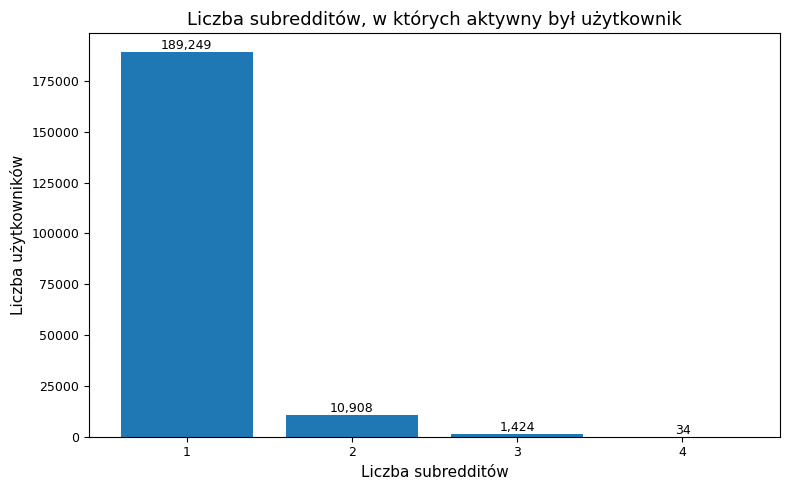

,total_comments,subreddits
author,,
MorrisFae,2205,"Metal, hiphopheads, indieheads, popheads"
CaptainOvbious,1714,"Metal, hiphopheads, indieheads, popheads"
Ktulusanders,1179,"Metal, hiphopheads, indieheads, popheads"
riddhishb,688,"Metal, hiphopheads, indieheads, popheads"
OLD_GREGG420,684,"Metal, hiphopheads, indieheads, popheads"
lanternsinthesky,423,"Metal, hiphopheads, indieheads, popheads"
boner_4ever,394,"Metal, hiphopheads, indieheads, popheads"
MangoMiasma,292,"Metal, hiphopheads, indieheads, popheads"
______________-__-,267,"Metal, hiphopheads, indieheads, popheads"


In [23]:
user_subreddit_count = df.groupby('author')['subreddit'].nunique()
user_subreddit_distribution = user_subreddit_count.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(user_subreddit_distribution.index, user_subreddit_distribution.values)
ax.set_title('Liczba subredditów, w których aktywny był użytkownik')
ax.set_xlabel('Liczba subredditów')
ax.set_ylabel('Liczba użytkowników')
ax.set_xticks(user_subreddit_distribution.index)

for x, y in zip(user_subreddit_distribution.index, user_subreddit_distribution.values):
    ax.text(x, y, f'{y:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'user_subreddit_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

users_in_all_subreddits = set.intersection(*subreddit_users.tolist()) if len(subreddit_users) > 0 else set()
users_in_all_df = (
    df[df['author'].isin(users_in_all_subreddits)]
    .groupby('author')
    .agg(total_comments=('comment_id', 'count'), subreddits=('subreddit', lambda x: ', '.join(sorted(set(x)))))
    .sort_values('total_comments', ascending=False)
)
users_in_all_df.to_csv(REPORTS_DIR / 'users_active_in_all_subreddits.csv')
users_in_all_df.head(20)

Analiza wspólnych użytkowników pozwala sprawdzić, czy społeczności muzyczne są od siebie odseparowane, czy też występuje między nimi przepływ uczestników. Użytkownicy aktywni w kilku subredditach mogą pełnić rolę pomostów między różnymi fandomami muzycznymi, choć sama obecność w wielu grupach nie oznacza jeszcze wysokiej pozycji w sieci interakcji.

## 7. Użytkownicy o najwyższej centralności w sieci

W tej części zamiast określenia „influencerzy” stosowane jest bardziej neutralne pojęcie „użytkownicy o najwyższej centralności”. Wskaźnik `influence_score` ma charakter pomocniczy i autorski. Jest liczony jako średnia z trzech znormalizowanych miar: degree centrality, betweenness centrality oraz liczby komentarzy autora w danym subreddicie.

Ograniczenie tego wskaźnika polega na tym, że nie mierzy on realnego wpływu społecznego, jakości wypowiedzi ani odbioru komentarzy przez innych użytkowników. Pokazuje jedynie, którzy użytkownicy jednocześnie często komentują, mają wiele relacji i mogą łączyć różne części sieci.

In [24]:
comment_counts = (
    df.groupby(['subreddit', 'author'])['comment_id']
    .count()
    .rename('comment_count')
    .reset_index()
)

influence_tables = []
for subreddit, centrality_df in centrality_tables.items():
    temp = centrality_df.reset_index().merge(
        comment_counts[comment_counts['subreddit'] == subreddit],
        on=['subreddit', 'author'],
        how='left'
    )
    temp['comment_count'] = temp['comment_count'].fillna(0)
    
    for column in ['degree_centrality', 'betweenness_centrality', 'comment_count']:
        temp[f'{column}_norm'] = normalize_series(temp[column])
    
    temp['influence_score'] = temp[[
        'degree_centrality_norm',
        'betweenness_centrality_norm',
        'comment_count_norm'
    ]].mean(axis=1)
    influence_tables.append(temp)

influence_df = pd.concat(influence_tables, ignore_index=True)
influence_df.to_csv(REPORTS_DIR / 'network_influence_score.csv', index=False)

top_influence_df = (
    influence_df
    .sort_values(['subreddit', 'influence_score'], ascending=[True, False])
    .groupby('subreddit')
    .head(10)
)
top_influence_df.to_csv(REPORTS_DIR / 'top_structurally_central_users.csv', index=False)
top_influence_df[['subreddit', 'author', 'degree_centrality', 'betweenness_centrality', 'comment_count', 'influence_score']]

,subreddit,author,degree_centrality,betweenness_centrality,comment_count,influence_score
49,Metal,whoelsebut_rxe,0.055298,0.031067,942,0.982245
327,Metal,onairmastering,0.050568,0.030196,995,0.962153
104,Metal,sardonic_malcontent,0.054752,0.028470,849,0.919937
38,Metal,Towering_Flesh,0.053934,0.027189,895,0.916670
154,Metal,kaptain_carbon,0.045566,0.021215,841,0.784039
94,Metal,an_altar_of_plagues,0.045839,0.018708,723,0.719261
140,Metal,WowboyKid,0.043565,0.015425,766,0.684729
197,Metal,hermaphroditicspork,0.045111,0.015341,731,0.681430
395,Metal,Samccx19,0.041655,0.018940,593,0.652975
134,Metal,ThePiperMan,0.040382,0.017837,603,0.636818


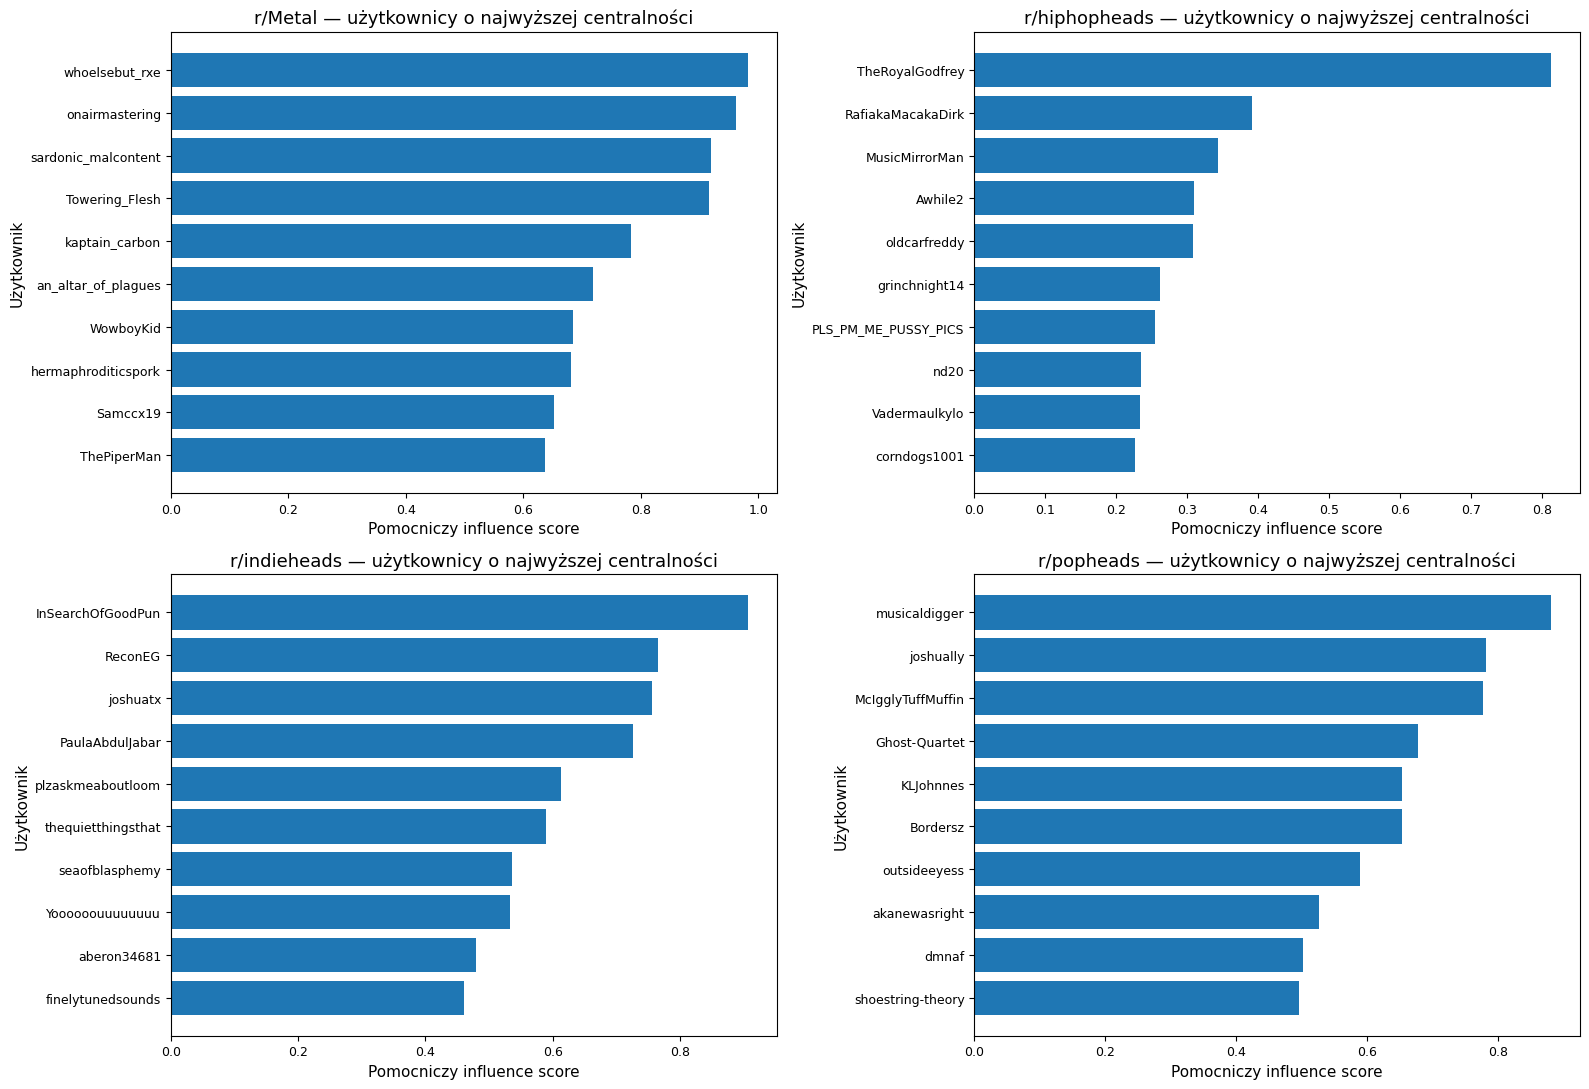

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, sorted(top_influence_df.groupby('subreddit'))):
    top = group.sort_values('influence_score', ascending=True)
    ax.barh(top['author'], top['influence_score'])
    ax.set_title(f"{subreddit_display(subreddit)} — użytkownicy o najwyższej centralności")
    ax.set_xlabel('Pomocniczy wskaźnik wpływu')
    ax.set_ylabel('Użytkownik')

for ax in axes[top_influence_df['subreddit'].nunique():]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_structurally_central_users.png', dpi=150, bbox_inches='tight')
plt.show()

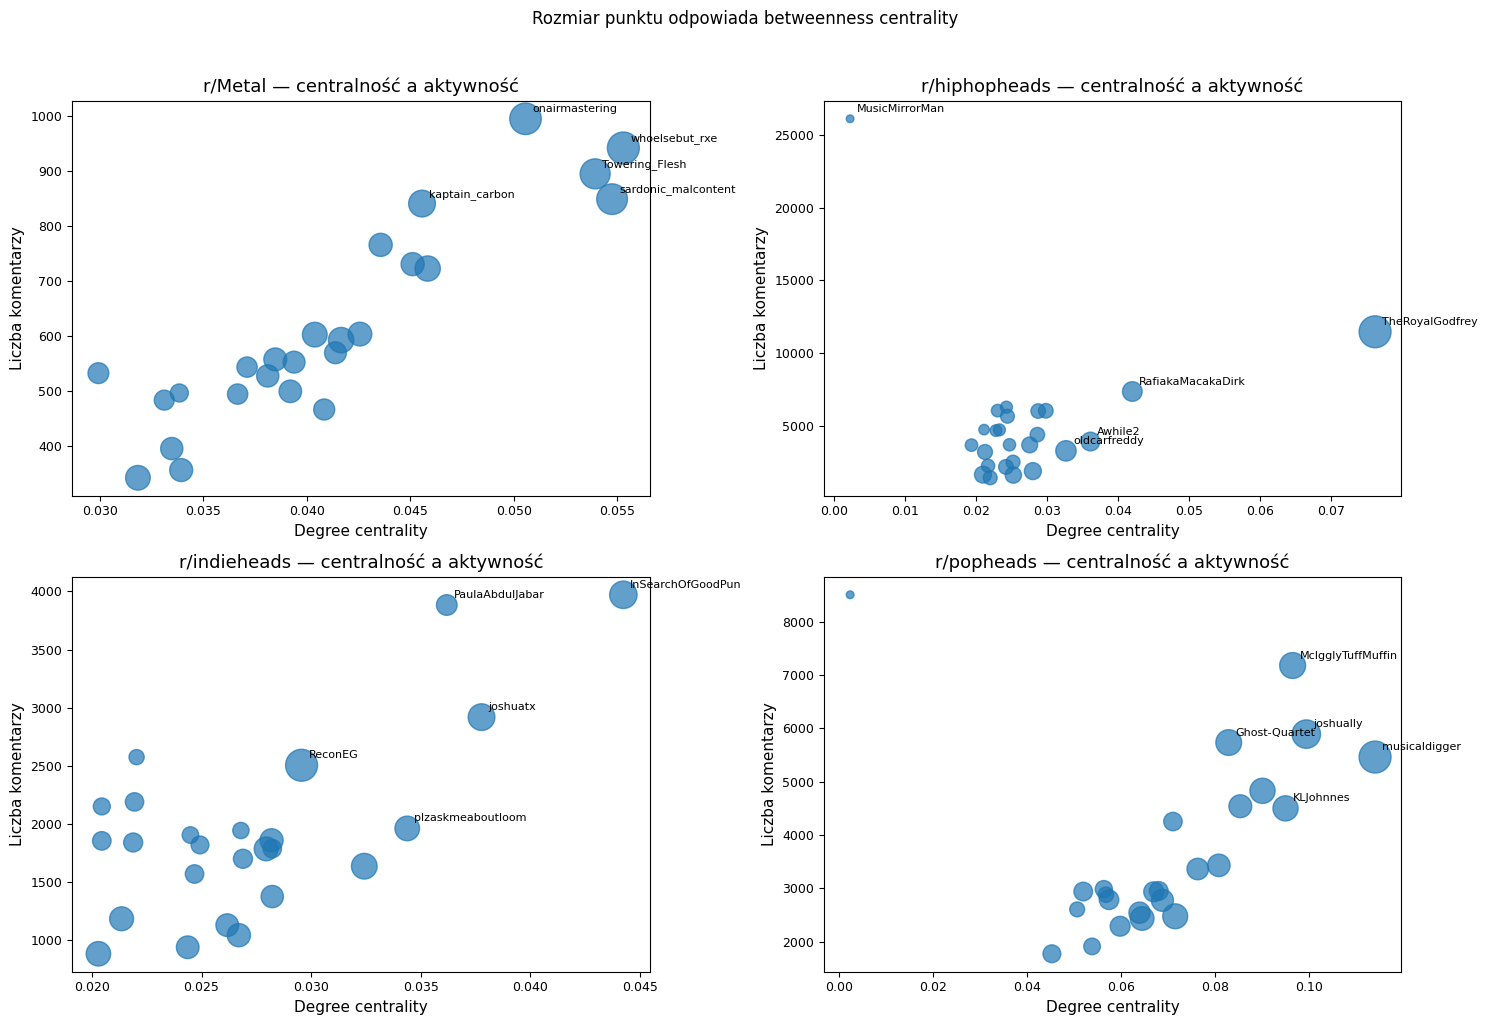

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, sorted(influence_df.groupby('subreddit'))):
    top_group = group.sort_values('influence_score', ascending=False).head(25)
    sizes = top_group['betweenness_centrality_norm'].fillna(0) * 500 + 30
    ax.scatter(top_group['degree_centrality'], top_group['comment_count'], s=sizes, alpha=0.7)

    for _, row in top_group.head(5).iterrows():
        ax.annotate(
            row['author'],
            (row['degree_centrality'], row['comment_count']),
            textcoords='offset points',
            xytext=(5, 5),
            fontsize=8,
        )

    ax.set_title(f"{subreddit_display(subreddit)} — centralność a aktywność")
    ax.set_xlabel('Centralność stopnia')
    ax.set_ylabel('Liczba komentarzy')

for ax in axes[influence_df['subreddit'].nunique():]:
    ax.axis('off')

plt.suptitle('Rozmiar punktu odpowiada centralności pośrednictwa', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'centrality_vs_activity.png', dpi=150, bbox_inches='tight')
plt.show()

Najwyższy wynik pomocniczego wskaźnika centralności uzyskują użytkownicy łączący aktywność komentarzową z silną pozycją w grafie odpowiedzi. W interpretacji należy jednak zachować ostrożność: wysoka centralność nie musi oznaczać autorytetu, popularności ani pozytywnego odbioru przez społeczność.

## Wnioski z analizy sieci społecznościowych

Analiza sieciowa umożliwia spojrzenie na społeczności muzyczne Reddita nie tylko przez treść komentarzy, lecz także przez strukturę interakcji między użytkownikami. Graf odpowiedzi pokazuje, które subreddity mają bardziej rozproszony model rozmów, a które skupiają się wokół mniejszej liczby aktywnych uczestników.

Podstawowe statystyki sieci, takie jak liczba węzłów, liczba krawędzi, gęstość i wielkość największej składowej, pozwalają porównać intensywność komunikacji w poszczególnych społecznościach. Metryki centralności wskazują użytkowników zajmujących ważne pozycje strukturalne, natomiast analiza społeczności pokazuje, czy w obrębie subredditów powstają wyraźne klastry dyskusyjne.

Wyniki należy interpretować w kontekście specyfiki Reddita. Relacje w grafie wynikają wyłącznie z odpowiedzi w komentarzach, dlatego nie obejmują biernego czytania, głosowania, reputacji użytkowników ani jakości wypowiedzi. Mimo tych ograniczeń analiza sieci dobrze uzupełnia wcześniejszą eksplorację danych i text mining, ponieważ pokazuje społeczną strukturę dyskusji wokół różnych gatunków muzycznych.

## Reset środowiska po restarcie kernela

In [ ]:
# =========================================================
# ODTWORZENIE ŚRODOWISKA — 03_network_analysis_uporzadkowany
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from collections import Counter, defaultdict
from itertools import combinations, permutations

try:
    from community import community_louvain

    LOUVAIN_AVAILABLE = True
except ImportError:
    community_louvain = None
    LOUVAIN_AVAILABLE = False

try:
    import plotly.graph_objects as go

    PLOTLY_AVAILABLE = True
except ImportError:
    go = None
    PLOTLY_AVAILABLE = False

# =========================
# Sciezki
# =========================

# Katalogi sa zdefiniowane w pierwszej komorce konfiguracyjnej.
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

NETWORK_DF_CHECKPOINT = CHECKPOINT_DIR / "network_df_checkpoint.pkl"

# =========================
# Ustawienia wykresów
# =========================

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

# =========================
# Wczytanie danych
# =========================

if NETWORK_DF_CHECKPOINT.exists():
    print("Wczytuję checkpoint ramki danych sieci...")
    df = pd.read_pickle(NETWORK_DF_CHECKPOINT)
    print(f"Wczytano df z checkpointu: {df.shape}")

elif DATA_PATH.exists():
    print("Wczytuję dane z CSV...")
    df = pd.read_csv(DATA_PATH)
    print(f"Wczytano df z CSV: {df.shape}")

    required_columns = {"author", "parent_id", "comment_id", "subreddit"}
    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        raise ValueError(f"Brakuje wymaganych kolumn: {missing_columns}")

    print("Czyszczenie ramki danych sieci...")

    df = df.copy()
    df["author"] = df["author"].astype(str)
    df["parent_id"] = df["parent_id"].astype(str)
    df["comment_id"] = df["comment_id"].astype(str)
    df["subreddit"] = df["subreddit"].astype(str)

    bot_pattern = r"bot$|automod|moderator|transcrib|helper"

    valid_mask = (
        df["author"].notna()
        & ~df["author"].isin(["[deleted]", "[removed]", "nan", "None"])
        & ~df["author"].str.lower().str.contains(bot_pattern, regex=True, na=False)
    )

    df = df.loc[valid_mask].copy()

    print(f"Oczyszczono df: {df.shape}")

    df.to_pickle(NETWORK_DF_CHECKPOINT)
    print(f"Zapisano checkpoint df: {NETWORK_DF_CHECKPOINT}")

else:
    raise FileNotFoundError(f"Nie znaleziono pliku danych: {DATA_PATH}")

# =========================
# Podsumowanie
# =========================

summary = pd.DataFrame(
    {
        "wartość": [
            len(df),
            df["author"].nunique(),
            df["subreddit"].nunique(),
            ", ".join(sorted(df["subreddit"].unique())),
        ]
    },
    index=[
        "liczba komentarzy po czyszczeniu",
        "liczba unikalnych użytkowników",
        "liczba subredditów",
        "analizowane subreddity",
    ],
)

summary.to_csv(REPORTS_DIR / "network_dataset_summary.csv")

print("\nŚrodowisko odtworzone.")
print(f"LOUVAIN_AVAILABLE: {LOUVAIN_AVAILABLE}")
print(f"PLOTLY_AVAILABLE: {PLOTLY_AVAILABLE}")
print(f"FIGURES_DIR: {FIGURES_DIR}")
print(f"REPORTS_DIR: {REPORTS_DIR}")

display(summary)

Loading network dataframe checkpoint...
Loaded df from checkpoint: (2541741, 10)

Environment restored.
LOUVAIN_AVAILABLE: True
PLOTLY_AVAILABLE: True
FIGURES_DIR: ..\outputs\figures
REPORTS_DIR: ..\outputs\reports


,wartość
liczba komentarzy po czyszczeniu,2541741
liczba unikalnych użytkowników,201615
liczba subredditów,4
analizowane subreddity,"Metal, hiphopheads, indieheads, popheads"
